In [33]:
import torch.nn as nn
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as T
from utils import *
from torch.utils.data import DataLoader
from models import *
import random
from collections import Counter
from collections import OrderedDict
import seaborn as sns
import copy
import numpy as np
import matplotlib.pyplot as plt

cos = nn.CosineSimilarity(dim=0, eps=1e-9)
device = "cuda"

# study 1 model's training with the new loss function with dist limits

# adjustable parameters
alpha_d = 100 # IID
n_clients = 100 # dataset size for one client
global attack 
attack = "untargeted" #"backdoor", "tlp", "ut"
model_name = "ConvNet" # "resnet8", "ConvNet"
num_classes = 10
dataset ="fmnist" # "cifar10", "fmnist"

In [34]:
def filter_trainable_state_dict(model):
    """
    Filters model.state_dict() to retain only parameters that are in model.parameters().

    Args:
        model (torch.nn.Module): The model whose state_dict needs filtering.

    Returns:
        dict: Filtered state dictionary containing only trainable parameters.
    """
    param_names = {name for name, _ in model.named_parameters()}
    return {k: v for k, v in model.state_dict().items() if k in param_names}


In [35]:
def cos_dist(w1, w2):
    """Compute cosine similarity between two flattened weight tensors"""
    w1_flat, w2_flat = torch.cat([p.view(-1) for p in w1]), torch.cat([p.view(-1) for p in w2])
    return 1 - torch.dot(w1_flat, w2_flat) / (torch.norm(w1_flat) * torch.norm(w2_flat))


def restore_dict_w_flat(param_flat, model_dict):
    restored_w = {}
    start = 0
    for name, param in model_dict.items():
            num_elements = param.numel()
            restored_w[name] = param_flat[start:start + num_elements].view(param.shape)                          
            start += num_elements
    return restored_w

def model_eval(model, test_loader, attack):
    acc = eval_op_ensemble([model], test_loader)
    if attack == "tlp":
        asr = eval_op_ensemble_tr_lf_attack([model], test_loader)
    elif attack == "backdoor":
        asr = eval_op_ensemble_attack([model], test_loader)
    elif attack == "untargeted":
        asr = None
    return list(acc.values())[0], list(asr.values())[0]


def filter_trainable_state_dict(model):
    """
    Filters model.state_dict() to retain only parameters that are in model.parameters().

    Args:
        model (torch.nn.Module): The model whose state_dict needs filtering.

    Returns:
        dict: Filtered state dictionary containing only trainable parameters.
    """
    param_names = {name for name, _ in model.named_parameters()}
    return {k: v for k, v in model.state_dict().items() if k in param_names}



def map_to_range(x, a, k=1):
    """Maps [0, +inf] to [a, 0] using an exponential decay function."""
    return a * (torch.exp(k * x))

def regularized_cross_entropy(x, a=2, k=1):
    return a * (1 - torch.exp(k * x))


def log_cosh_cross_entropy_loss(preds, targets):
    ce_loss = F.cross_entropy(preds, targets, reduction='none')  # Standard cross-entropy
    return torch.mean(torch.log(torch.cosh(ce_loss)))  # Apply log-cosh

def stable_log_cosh_cross_entropy_loss(preds, targets):
    ce_loss = F.cross_entropy(preds, targets, reduction='none')  # Standard CE loss
    stable_loss = torch.abs(ce_loss) + torch.log1p(torch.exp(-2 * torch.abs(ce_loss))) - torch.log(torch.tensor(2.0))
    return torch.mean(stable_loss)

def train_rev_w_cos(model, loader, optimizer, scheduler, epochs, model0, beta, budget):    
    model.train()
    # model.parameters need to use 
    flat_model0 = flat_dict(filter_trainable_state_dict(model0))
    
    losses = []
    running_loss, samples = 0.0, 0
    print(f"data length {len(loader) * loader.batch_size}: batches {len(loader)}, batch_size {loader.batch_size}")
    
    last_mail_w = flat_model0.clone().detach()
    for ep in range(epochs):
        for it, (x, y) in enumerate(loader):
            if it % 2 == 0:
                losses.append(round(eval_epoch(model, loader), 2))
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            
            # 1 negative CE loss
            loss_ce = nn.CrossEntropyLoss(reduction="mean")(model(x), y)
            loss_oppo_ce = - loss_ce

            running_loss += loss_oppo_ce.item() * y.shape[0]
            samples += y.shape[0]
            
            # add cos loss 
            w = torch.cat([p.view(-1) for p in model.parameters()]).to(device)
            target = torch.ones(len(w)).to(device)
            loss_cos = nn.CosineEmbeddingLoss()(flat_model0.unsqueeze(0), w.unsqueeze(0), target)
            
            # total_loss_magnitude = loss_oppo_ce + loss_cos
            # normalized_loss_oppo_ce = (loss_oppo_ce / total_loss_magnitude)
            # normalized_loss_cos = (loss_cos / total_loss_magnitude)
            
            # opt1: combindation loss
            loss_obj = (1-beta) * loss_oppo_ce + beta * loss_cos
            # loss_obj = (1-beta) * normalized_loss_oppo_ce + beta * normalized_loss_cos
            
            # opt2: only negative loss
            # loss_obj = loss_oppo_ce 
            
            # opt3: domain conversion
            # loss_obj = map_to_range(x=loss_ce, a=2, k=0.01) + loss_cos # can not enlarge the loss_cos
            # loss_obj = regularized_cross_entropy(x=loss_ce, a=2, k=0.01) + loss_cos
            
            # opt4: 
            # loss_obj = 1 / (1 + math.exp(1-loss_ce)) + loss_cos
            
            # opt5: Robust Log-Cosh Loss
            # loss_obj = (1-beta) * (- stable_log_cosh_cross_entropy_loss(model(x), y)) + beta * loss_cos
            
            loss_obj.backward()
            optimizer.step()
            scheduler.step()
            if it % 5 == 0:
                print(f"ep{ep}, loss_oppo_ce: {loss_oppo_ce:.2f}, loss_cos: {loss_cos:.6f}, loss_obj: {loss_obj:.2f}, lr: {optimizer.param_groups[0]['lr']}, beta: {beta}")
        
        # beta = (-loss_oppo_ce / (-loss_oppo_ce +loss_cos) * beta).detach()
        
        # break
        crafted_cos_d = cos_dist_w(flat_model0, w)
        print(f"cos_d: {crafted_cos_d}, budget: {budget}")

        if crafted_cos_d > budget:
            print(f"budget exceeded, finish training early, ep = {ep}")
            break
        
        last_mail_w = w
        
    # craft_g = combine_tensors(B=grad_ben, M=grad_mail, budget=budget)
    craft_w = craft_tensor(B=flat_model0, M1=last_mail_w, M2=w, k=budget)
    
    # restored_crafted = restore_dict_grad_flat(craft_w, model0.state_dict(), model.state_dict())
    restored_crafted = restore_dict_w_flat(craft_w, model.state_dict())
    model.load_state_dict(restored_crafted)
    crafted_cos_d = cos_dist_w(flat_model0, craft_w)
        
    print(f"crafted cos_d: {crafted_cos_d}")        

    return {"loss": running_loss / samples}
    

In [36]:
# Define transformation (convert images to tensors and normalize)
transform_img = T.Compose([
    T.ToTensor(),  # Convert image to tensor
    T.Normalize((0.5,), (0.5,))  # Normalize the image with mean and std
])

if dataset == "fmnist":
    # Load the training dataset
    train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_img)
    # Load the test dataset
    test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_img)
elif dataset == "cifar10":
    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_img)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_img)

# Create DataLoader for batch processing
client_loaders, test_loader, client_data_subsets =\
    data.get_loaders(train_data, test_data, n_clients,
                    alpha=alpha_d, batch_size=32, n_data=None, num_workers=4, seed=4)
    
model_fn = partial(models.get_model(model_name)[
                        0], num_classes=num_classes, dataset=dataset)

client_loader = client_loaders[0]

# created models 
model0 = model_fn().to(device) # orginal model
model1 = model_fn().to(device) # train with clean data
model2 = model_fn().to(device) # train with new loss function
modelt1 = model_fn().to(device)
modelt0 = model_fn().to(device)

model0_sd = {k: v.clone().detach() for k, v in model0.state_dict().items()}

optimizer0 = optim.SGD(model0.parameters(), lr=0.001)
optimizer1 = optim.SGD(model1.parameters(), lr=0.001)

optimizer3 = optim.SGD(modelt1.parameters(), lr=0.001)



Data split:
 - Client 0: [62 62 58 65 57 61 58 53 56 63]                         -> sum=595
 - Client 1: [61 64 63 55 59 58 60 65 57 58]                         -> sum=600
 - Client 2: [54 57 59 60 64 66 62 63 60 54]                         -> sum=599
 - Client 3: [62 56 63 56 62 63 59 58 61 61]                         -> sum=601
 - Client 4: [57 67 62 56 57 65 65 57 54 58]                         -> sum=598
 - Client 5: [54 51 65 59 66 67 53 57 62 68]                         -> sum=602
 - Client 6: [61 65 60 67 53 60 61 50 58 66]                         -> sum=601
 - Client 7: [53 58 49 70 75 63 51 61 54 64]                         -> sum=598
 - Client 8: [64 58 60 52 59 66 65 64 55 59]                         -> sum=602
 - Client 9: [58 63 46 68 61 56 57 66 69 55]                         -> sum=599
.  .  .  .  .  .  .  .  .  .  
.  .  .  .  .  .  .  .  .  .  
.  .  .  .  .  .  .  .  .  .  
 - Client 91: [54 61 56 53 60 63 63 62 70 58]                         -> sum=600
 - Client 92: 

In [37]:
# num of the iteration
t = 2

In [38]:
# model1 train benign t-1
model1.load_state_dict(model0_sd)
train_op(model1, client_loader, optimizer1, epochs=t-1, print_train_loss=True)

model1_t0 = {key: value.clone() for key, value in model1.state_dict().items()}
model1_t0_acc = eval_op_ensemble([model1], test_loader)
model1_t0_acc

Epoches 1, Loss History: [2.28], lr: 0.001


{'test_accuracy': 0.4899}

In [39]:
# one more iteration for t
train_op(model1, client_loader, optimizer1, epochs=1, print_train_loss=True)

model1_t1 = {key: value.clone() for key, value in model1.state_dict().items()}
model1_t1_acc = eval_op_ensemble([model1], test_loader)
model1_t1_acc

Epoches 1, Loss History: [1.93], lr: 0.001


{'test_accuracy': 0.6088}

In [40]:
# one more iteration for t+1
train_op(model1, client_loader, optimizer1, epochs=1, print_train_loss=True)

model1_t2 = {key: value.clone() for key, value in model1.state_dict().items()}
model1_t2_acc = eval_op_ensemble([model1], test_loader)
model1_t2_acc

Epoches 1, Loss History: [1.7], lr: 0.001


{'test_accuracy': 0.6471}

In [41]:
modelt1.load_state_dict(model1_t1)

<All keys matched successfully>

In [42]:
def mali_model_craft_w_budget(model1, model2, model0, client_loader, budget):
    # model2 train with new loss function
    optimizer2 = optim.SGD(model2.parameters(), lr=0.005) # 0.001
    scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=1)

    model2.load_state_dict(model1.state_dict())
    model2_result_before = eval_op_ensemble([model2], test_loader)
    
    train_rev_w_cos(model2, client_loader, optimizer2, scheduler2, epochs=12, 
                                    model0 = model0, 
                                    beta = 0.5, 
                                    budget = budget)
    
    cos_d = cos_dist(flat_dict(filter_trainable_state_dict(model1)),
                         flat_dict(filter_trainable_state_dict(model2)))
    
    model2_result = eval_op_ensemble([model2], test_loader)
    
    return cos_d, model2_result, model2_result_before 

In [43]:
mali_model_craft_w_budget(modelt1, model2, modelt1, client_loader, budget=0.001)

data length 608: batches 19, batch_size 32
ep0, loss_oppo_ce: -1.67, loss_cos: 0.000000, loss_obj: -0.83, lr: 0.005, beta: 0.5
ep0, loss_oppo_ce: -1.83, loss_cos: 0.000002, loss_obj: -0.92, lr: 0.005, beta: 0.5
ep0, loss_oppo_ce: -1.95, loss_cos: 0.000010, loss_obj: -0.97, lr: 0.005, beta: 0.5
ep0, loss_oppo_ce: -2.66, loss_cos: 0.000026, loss_obj: -1.33, lr: 0.005, beta: 0.5
cos_d: 5.793571472167969e-05, budget: 0.001
ep1, loss_oppo_ce: -5.27, loss_cos: 0.000081, loss_obj: -2.64, lr: 0.005, beta: 0.5
ep1, loss_oppo_ce: -11.82, loss_cos: 0.000297, loss_obj: -5.91, lr: 0.005, beta: 0.5
ep1, loss_oppo_ce: -19.85, loss_cos: 0.000676, loss_obj: -9.93, lr: 0.005, beta: 0.5
ep1, loss_oppo_ce: -29.33, loss_cos: 0.001296, loss_obj: -14.66, lr: 0.005, beta: 0.5
cos_d: 0.001751720905303955, budget: 0.001
budget exceeded, finish training early, ep = 1
alpha_tensor 0.2842787206172943
crafted cos_d: 0.0009999871253967285


/home2/liyang/GitHub/FedREDefense/codes/utils.py:2128: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  alpha = fsolve(objective, alpha_initial_guess)[0]


(tensor(0.0010, device='cuda:0'),
 {'test_accuracy': 0.1},
 {'test_accuracy': 0.6088})

In [44]:
cos_dist(flat_dict(filter_trainable_state_dict(model1)),
                         flat_dict(filter_trainable_state_dict(model2)))

tensor(0.0010, device='cuda:0')

## if norm are the same

In [45]:
flat_grad_benign = flat_dict(filter_trainable_state_dict(model1)) - flat_dict(filter_trainable_state_dict(modelt1))
flat_grad_mali = flat_dict(filter_trainable_state_dict(model2)) - flat_dict(filter_trainable_state_dict(modelt1))

torch.norm(flat_grad_benign, p=2), torch.norm(flat_grad_mali, p=2)

(tensor(0.0569, device='cuda:0'), tensor(1.0228, device='cuda:0'))

In [46]:
# normalize the flat_grad_mali
flat_grad_mali = flat_grad_mali / torch.norm(flat_grad_mali, p=2) * torch.norm(flat_grad_benign, p=2) 
torch.norm(flat_grad_benign, p=2), torch.norm(flat_grad_mali, p=2)

(tensor(0.0569, device='cuda:0'), tensor(0.0569, device='cuda:0'))

In [47]:
r_w = restore_dict_grad_flat(flat_grad_mali, model1_t1, model0.state_dict())
model2.load_state_dict(r_w)
eval_op_ensemble([model2], test_loader)

missing_keys set()


{'test_accuracy': 0.2289}

In [48]:
modelt0.load_state_dict(model1_t0)
flat_grad_t_0_t1 = flat_dict(filter_trainable_state_dict(modelt0)) - flat_dict(filter_trainable_state_dict(model2))
torch.norm(flat_grad_t_0_t1, p=2)

tensor(0.0759, device='cuda:0')

In [49]:
def get_cosdist_among_models(models):
    m = []
    for i in range(len(models)):
        dist = []
        for j in range(len(models)):
            dist.append(cos_dist(flat_dict(filter_trainable_state_dict(models[i])),
                         flat_dict(filter_trainable_state_dict(models[j]))).item()
                       )
        m.append(dist)
    return m


def get_l2_among_models(models):
    m = []
    for i in range(len(models)):
        dist = []
        for j in range( len(models)):
            dist.append(torch.norm(flat_dict(filter_trainable_state_dict(models[i]))-
                         flat_dict(filter_trainable_state_dict(models[j]))).item()
                       )
        m.append(dist)
    return m

In [50]:
# our models
models = [modelt0, modelt1, model1, model2 ]
cos_matrix = get_cosdist_among_models(models)
L2_matrix = get_l2_among_models(models)

In [51]:
L2_matrix

[[0.0, 0.06717928498983383, 0.12318774312734604, 0.07592035830020905],
 [0.06717928498983383, 0.0, 0.056858427822589874, 0.05685843154788017],
 [0.12318774312734604, 0.056858427822589874, 0.0, 0.09130438417196274],
 [0.07592035830020905, 0.05685843154788017, 0.09130438417196274, 0.0]]

In [52]:
# get all models's accuracy at once
acc_list = []
for model in models:
    acc = eval_op_ensemble([model], test_loader)
    print(acc)
    acc_list.append(list(acc.values())[0])
acc_list

{'test_accuracy': 0.4899}
{'test_accuracy': 0.6088}
{'test_accuracy': 0.6471}
{'test_accuracy': 0.2289}


[0.4899, 0.6088, 0.6471, 0.2289]

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE



def visualize_distance_matrix_tsne_lines(dist_matrix, labels, perplexity=2, random_state=42, title="", times=1e6):
    """Visualizes a distance matrix using t-SNE in 2D with lines between nodes showing distances."""
    tsne = TSNE(n_components=2, metric='precomputed', perplexity=perplexity, init='random', random_state=random_state)
    coords = tsne.fit_transform(dist_matrix)
    
    plt.figure(figsize=(6, 6))

    # Plot nodes
    plt.scatter(coords[:, 0], coords[:, 1], color='blue')

    # Highlight the last node in red
    plt.scatter(coords[-1, 0], coords[-1, 1], color='red')

    # Label each node
    for i, label in enumerate(labels):
        plt.text(coords[i, 0], coords[i, 1], label, fontsize=12, ha='right')

    # Draw lines between nodes with distance labels
    for i in range(len(coords)):
        for j in range(i+1, len(coords)):
            distance = dist_matrix[i, j]
            mid_point = (coords[i] + coords[j]) / 2
            # Display only the numeric part of the distance
            plt.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]], color='gray', linestyle='--', alpha=0.5)
            plt.text(mid_point[0], mid_point[1], f'{distance*times:.2f}', fontsize=12, ha='center')

    # Add "e-02" to the legend
    plt.legend([f"{title} Distances (x 10^-{int(math.log10(times))})"], loc="upper right", fontsize=12)

    
    # Hide x and y labels and ticks
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks([])
    plt.yticks([])
    
    # plt.title(f"2D Representation of Models using t-SNE {title}")
    # plt.grid()
    plt.show()


def visualize_distance_matrix_tsne(dist_matrix, labels, perplexity=2, random_state=42, title=""):
    """Visualizes a distance matrix using t-SNE in 2D."""
    tsne = TSNE(n_components=2, metric='precomputed', perplexity=perplexity, init='random', random_state=random_state)
    coords = tsne.fit_transform(dist_matrix)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(coords[:, 0], coords[:, 1], color='blue')
    
    for i, label in enumerate(labels):
        plt.text(coords[i, 0], coords[i, 1], label, fontsize=12, ha='right')
    
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title(f"2D Representation of Models using t-SNE {title}")
    # plt.grid()
    plt.show()
    
# def visualize_distance_matrix_tsne_no_label(dist_matrix, labels, perplexity=2, random_state=42, title=""):
#     """Visualizes a distance matrix using t-SNE in 2D."""
#     tsne = TSNE(n_components=2, metric='precomputed', perplexity=perplexity, init='random', random_state=random_state)
#     coords = tsne.fit_transform(dist_matrix)
    
#     plt.figure(figsize=(6, 6))
#     plt.scatter(coords[:, 0], coords[:, 1], color='blue')
    
#     for i, label in enumerate(labels):
#         print(f"i: {i}, label: {label}")
#         plt.text(coords[i, 0], coords[i, 1], label, fontsize=12, ha='right')
    
#     # Hide x and y labels and ticks
#     plt.xlabel("")
#     plt.ylabel("")
#     plt.xticks([])
#     plt.yticks([])
    
#     plt.title(f"2D Representation of Models using t-SNE {title}")
#     plt.show()    

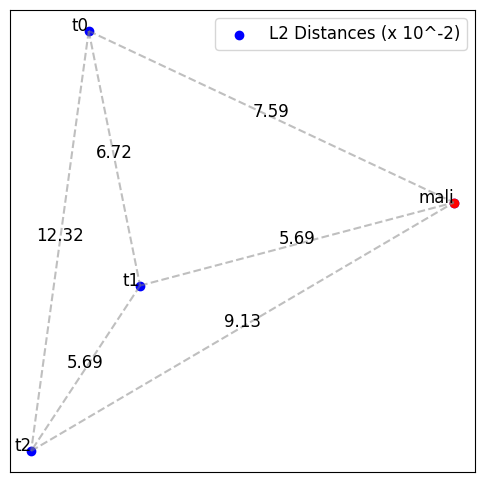

In [66]:
labels = ["t0", "t1", "t2", "mali"]
visualize_distance_matrix_tsne_lines(torch.tensor(L2_matrix), labels,  title="L2",random_state=40, times=1e2)

In [67]:
cos_matrix_positive = torch.tensor(cos_matrix)

min_value = cos_matrix_positive.min()

# If the minimum value is negative, shift all elements by adding its absolute value
if min_value < 0:
    cos_matrix_positive += abs(min_value)

In [68]:
cos_matrix_positive

tensor([[0.0000e+00, 4.3511e-06, 1.4544e-05, 5.4836e-06],
        [4.3511e-06, 0.0000e+00, 3.0398e-06, 3.0398e-06],
        [1.4544e-05, 3.0398e-06, 0.0000e+00, 7.8678e-06],
        [5.4836e-06, 3.0398e-06, 7.8678e-06, 0.0000e+00]])

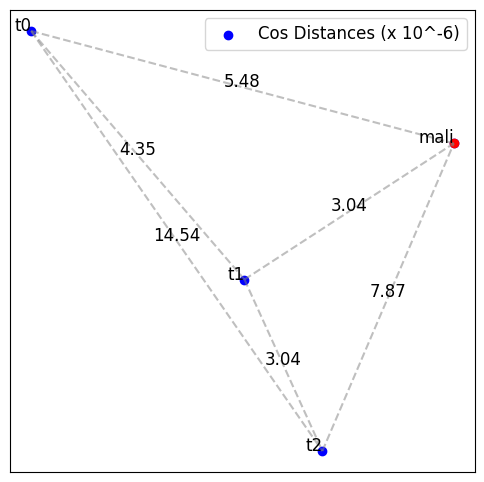

In [75]:
# visualize_distance_matrix_tsne(cos_matrix_positive, labels, title="cosine distance")
visualize_distance_matrix_tsne_lines(cos_matrix_positive, labels, title="Cos", random_state=31,  times=1e6)

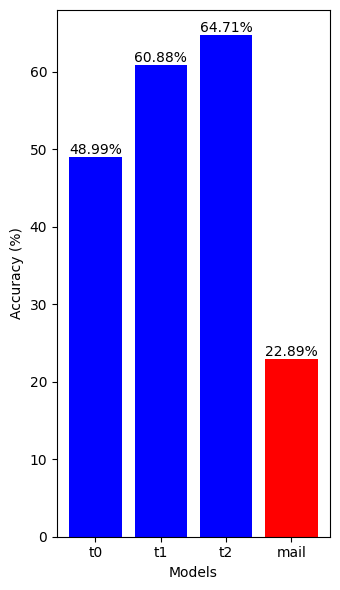

In [84]:
# Data
labels = ["t0", "t1", "t2", "mail"]
accuracy = acc_list

# Convert accuracy to percentages
accuracy_percent = [acc * 100 for acc in acc_list]

# Plotting
plt.figure(figsize=(3.5, 6))
bars = plt.bar(labels, accuracy_percent, color=['blue', 'blue', 'blue', 'red'])

# Adding numbers on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}%', 
             ha='center', va='bottom')

# Adding titles and labels
# plt.title('Model Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
# Display the plot
plt.show()

In [76]:
from sklearn.manifold import MDS
def visualize_distance_matrix(distance_matrix, labels=None, name=""):
    """
    Visualizes a distance matrix in 2D space using MDS.

    Parameters:
    - distance_matrix: A square matrix of pairwise distances.
    - labels: Optional list of labels for the nodes.
    """
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=39)
    coords = mds.fit_transform(distance_matrix)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], c='blue', edgecolors='black')

    if labels:
        for i, label in enumerate(labels):
            plt.text(coords[i, 0], coords[i, 1], str(label), fontsize=12, ha='right', va='bottom')

    plt.title(f"2D Visualization of Distance Matrix {name}")
    plt.xlabel("MDS Dimension 1")
    plt.ylabel("MDS Dimension 2")
    plt.grid(True)
    plt.show()

# # Example usage with a random symmetric distance matrix
# np.random.seed(0)
# n_nodes = 10
# random_distances = np.random.rand(n_nodes, n_nodes)
# random_distances = (random_distances + random_distances.T) / 2  # Symmetrize
# np.fill_diagonal(random_distances, 0)  # Set diagonal to 0

# visualize_distance_matrix(random_distances, labels=range(n_nodes))

In [107]:
# visualization of the layers
def compare_model_weights(model1, model2):
    """
    Compare the weights of two PyTorch models layer by layer using bar charts.
    
    Args:
        model1 (torch.nn.Module): The first model to compare.
        model2 (torch.nn.Module): The second model to compare.
    
    Returns:
        None (displays a bar chart of L2 distance and cosine dissimilarity).
    """
    layer_names = []
    l2_distances = []
    cos_dissimilarities = []
    
    for (name1, param1), (name2, param2) in zip(model1.named_parameters(), model2.named_parameters()):
        if name1 != name2:
            raise ValueError(f"Layer mismatch: {name1} vs {name2}")
        
        layer_names.append(name1)
        param1_flat = param1.view(-1)
        param2_flat = param2.view(-1)
        
        l2_distance = torch.norm(param1_flat - param2_flat, p=2).item()
        l2_distances.append(l2_distance)
        
        cos_sim = torch.nn.functional.cosine_similarity(param1_flat, param2_flat, dim=0).item()
        cos_dissimilarities.append(1 - cos_sim)
    
    
    flat_grad_model1 = flat_dict(filter_trainable_state_dict(model1))
    flat_grad_model2 = flat_dict(filter_trainable_state_dict(model2))
    layer_names.append("all")
    
    l2_distance = torch.norm(flat_grad_model1 - flat_grad_model2, p=2).item()
    l2_distances.append(l2_distance)
        
    cos_sim = torch.nn.functional.cosine_similarity(flat_grad_model1, flat_grad_model2, dim=0).item()
    cos_dissimilarities.append(1 - cos_sim)
    
    # Plot results as bar charts
    x = np.arange(len(layer_names))  # Layer indices
    width = 0.35  # Width of the bars

    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    # Bar chart for L2 Distance
    ax1.bar(x - width/2, l2_distances, width, label="L2 Distance", color='tab:blue')
    ax1.set_xlabel("Model Layer")
    ax1.set_ylabel("L2 Distance", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Bar chart for Cosine Dissimilarity
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, cos_dissimilarities, width, label="Cos Distance", color='tab:red')
    ax2.set_ylabel("Cos Distance", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    # Add layer names to x-axis
    plt.xticks(x, layer_names, rotation=45, ha='right')
    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)
    
    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    # Add title and layout adjustments
    # plt.title("Layer-wise L2 Distance and Cosine Dissimilarity (Bar Chart)")
    fig.tight_layout()
    plt.show()
    
    

def plot_model_parameters(model):
    """
    Plot the number of parameters for each layer of the given model.
    
    Args:
        model (torch.nn.Module): The model whose layer parameters will be plotted.
    
    Returns:
        None (saves the plot as an image).
    """
    layer_names = []
    num_parameters = []
    
    # Iterate over model parameters
    for name, param in model.named_parameters():
        layer_names.append(name)
        num_parameters.append(param.numel())  # Get the number of parameters for this layer
    
    # Plot results as a bar chart
    x = range(len(layer_names))  # Layer indices
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Bar chart for Number of Parameters
    ax.bar(x, num_parameters, color='tab:grey')
    
    ax.set_xlabel("Model Layer")
    ax.set_ylabel("Number of Parameters")
    # ax.set_title("Number of Parameters per Layer")
    
    # Add layer names to x-axis
    plt.xticks(x, layer_names, rotation=45, ha='right')
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
    
    # Save the plot as an image
    plt.tight_layout()
    # plt.savefig("model_parameters_plot.png")
    plt.show()


    

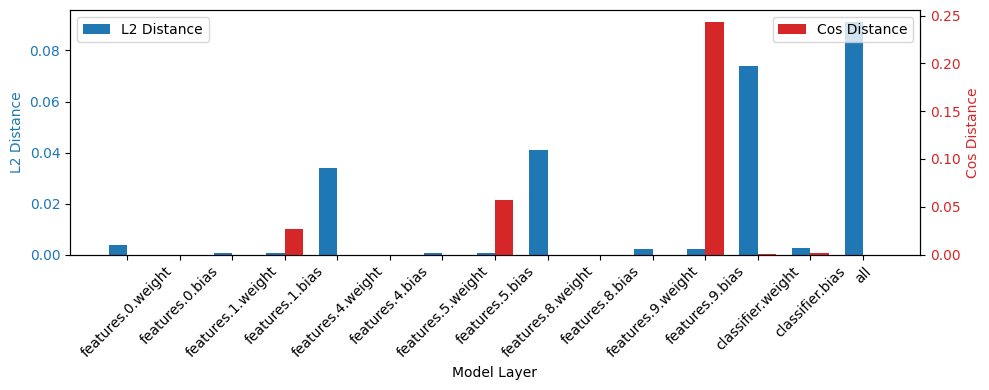

In [96]:
compare_model_weights(model1, model2)

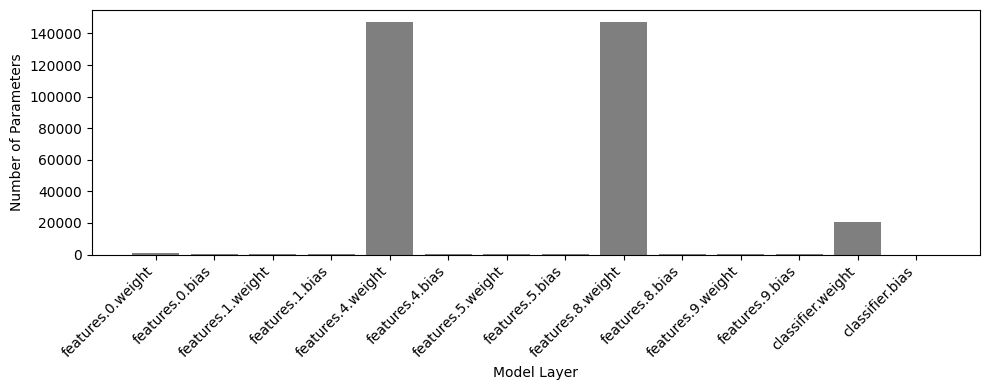

In [108]:
plot_model_parameters(model1)

In [158]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def compare_model_weights2(model1, model2):
    """
    Compare the weights of two PyTorch models layer by layer using bar charts.
    
    Args:
        model1 (torch.nn.Module): The first model to compare.
        model2 (torch.nn.Module): The second model to compare.
    
    Returns:
        None (displays a bar chart of L2 distance, cosine dissimilarity, and number of parameters).
    """
    layer_names = []
    l2_distances = []
    cos_dissimilarities = []
    num_parameters = []  # List to store the number of parameters for each layer
    
    for (name1, param1), (name2, param2) in zip(model1.named_parameters(), model2.named_parameters()):
        if name1 != name2:
            raise ValueError(f"Layer mismatch: {name1} vs {name2}")
        
        layer_names.append(name1)
        param1_flat = param1.view(-1)
        param2_flat = param2.view(-1)
        
        l2_distance = torch.norm(param1_flat - param2_flat, p=2).item()
        l2_distances.append(l2_distance)
        
        cos_sim = torch.nn.functional.cosine_similarity(param1_flat, param2_flat, dim=0).item()
        cos_dissimilarities.append(1 - cos_sim)
        
        # Calculate the number of parameters for this layer
        num_parameters.append(param1.numel())
    
    flat_grad_model1 = flat_dict(filter_trainable_state_dict(model1))
    flat_grad_model2 = flat_dict(filter_trainable_state_dict(model2))
    layer_names.append("all")
    
    l2_distance = torch.norm(flat_grad_model1 - flat_grad_model2, p=2).item()
    l2_distances.append(l2_distance)
        
    cos_sim = torch.nn.functional.cosine_similarity(flat_grad_model1, flat_grad_model2, dim=0).item()
    cos_dissimilarities.append(1 - cos_sim)
    
    # Calculate the total number of parameters
    num_parameters.append(flat_grad_model1.numel())
    
    # Plot results as bar charts
    x = np.arange(len(layer_names))  # Layer indices
    width = 0.25  # Adjust width for 3 bars
    
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    
    # Bar chart for L2 Distance
    ax1.bar(x - width, l2_distances, width, label="L2 Distance", color='tab:blue')
    ax1.set_xlabel("Model Layer")
    ax1.set_ylabel("L2 Distance", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Bar chart for Cosine Dissimilarity
    ax2 = ax1.twinx()
    ax2.bar(x, cos_dissimilarities, width, label="Cos Distance", color='tab:red')
    ax2.set_ylabel("Cos Distance", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Bar chart for Number of Parameters (background with lighter color)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))  # Offset ax3 further to the right
    ax3.bar(x + width, num_parameters, width, label="Num Parameters", color='tab:gray', alpha=0.3)
    ax3.set_ylabel("Num Parameters", color='tab:gray')
    ax3.tick_params(axis='y', labelcolor='tab:gray')
    
    # Add layer names to x-axis
    plt.xticks(x, layer_names, rotation=45, ha='right')
    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)
    
    # Add legends in separate positions to avoid overlap
    ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.99), ncol=1)
    ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.88), ncol=1)
    ax3.legend(loc='upper left', bbox_to_anchor=(0, 0.77), ncol=1)
    
    # Add title and layout adjustments
    fig.tight_layout()
    plt.show()


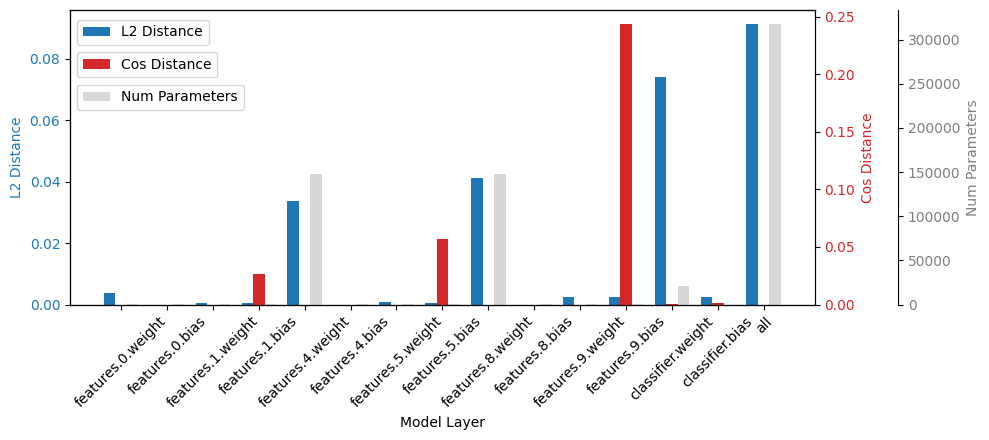

In [159]:
compare_model_weights2(model1, model2)

The L2 and Cosine distince is small in this attack

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch

def extract_layer_outputs(model, dataloader, device):
    """Extracts outputs from all layers of the model for the given dataset."""
    model.eval()
    outputs = {}
    hooks = []
    
    def register_hook(layer_name):
        def hook(module, inp, out):
            outputs[layer_name].append(out.detach().cpu().numpy())
        return hook
    
    # Register hooks for each layer
    for name, layer in model.named_modules():
        if isinstance(layer, torch.nn.Linear) or isinstance(layer, torch.nn.Conv2d):
            outputs[name] = []
            hooks.append(layer.register_forward_hook(register_hook(name)))
    
    # Forward pass
    with torch.no_grad():
        for batch in dataloader:
            inputs = batch[0].to(device)
            model(inputs)
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    # Stack layer outputs
    for name in outputs:
        outputs[name] = np.concatenate(outputs[name], axis=0)
    
    return outputs

def plot_tsne_layer_comparison(model1, model2, dataloader, device, perplexity=30, n_components=2, random_state=42):
    """Plots t-SNE for corresponding layers in two models with the same structure."""
    outputs1 = extract_layer_outputs(model1, dataloader, device)
    outputs2 = extract_layer_outputs(model2, dataloader, device)
    print("outputs1", outputs1.keys())
    print("outputs2", outputs2.keys())
    common_layers = set(outputs1.keys()) & set(outputs2.keys())

    if common_layers==set(outputs1.keys()):
        common_layers = outputs1.keys()
    print("common_layers", common_layers)
    
    for layer in common_layers:
        feat1 = outputs1[layer]
        feat2 = outputs2[layer]
        
        # Ensure same number of samples
        min_samples = min(len(feat1), len(feat2))
        feat1, feat2 = feat1[:min_samples], feat2[:min_samples]
        
        # Flatten features if necessary
        feat1 = feat1.reshape(min_samples, -1)
        feat2 = feat2.reshape(min_samples, -1)
        
        # Concatenate features from both models
        X = np.vstack((feat1, feat2))
        y = np.array([0] * min_samples + [1] * min_samples)  # Labels for model 1 and model 2
        
        tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
        X_embedded = tsne.fit_transform(X)
        
        plt.figure(figsize=(6, 4))
        plt.scatter(X_embedded[y == 0, 0], X_embedded[y == 0, 1], color='red', label='Benign', alpha=0.6)
        plt.scatter(X_embedded[y == 1, 0], X_embedded[y == 1, 1], color='blue', label='Mali', alpha=0.6)
        # plt.title(f't-SNE Visualization of Layer: {layer}')
        plt.legend()
        plt.show()

# Example usage:
# model1 and model2 should be instances of the same architecture trained on different data
# dataloader should provide inputs in batches
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# plot_tsne_layer_comparison(model1, model2, dataloader, device)


In [167]:
model1.state_dict().keys()

odict_keys(['features.0.weight', 'features.0.bias', 'features.1.weight', 'features.1.bias', 'features.4.weight', 'features.4.bias', 'features.5.weight', 'features.5.bias', 'features.8.weight', 'features.8.bias', 'features.9.weight', 'features.9.bias', 'classifier.weight', 'classifier.bias'])

outputs1 dict_keys(['features.0', 'features.4', 'features.8', 'classifier'])
outputs2 dict_keys(['features.0', 'features.4', 'features.8', 'classifier'])
common_layers dict_keys(['features.0', 'features.4', 'features.8', 'classifier'])


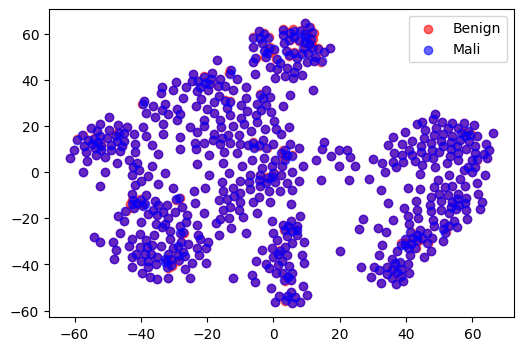

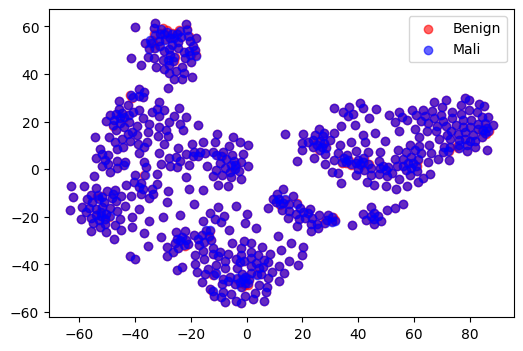

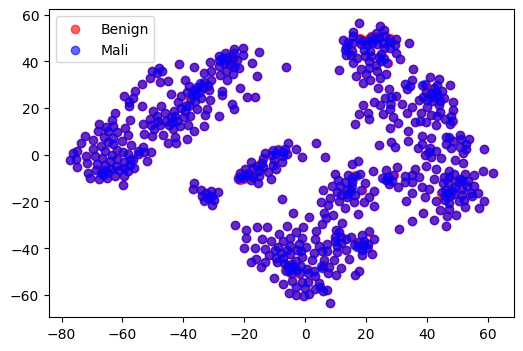

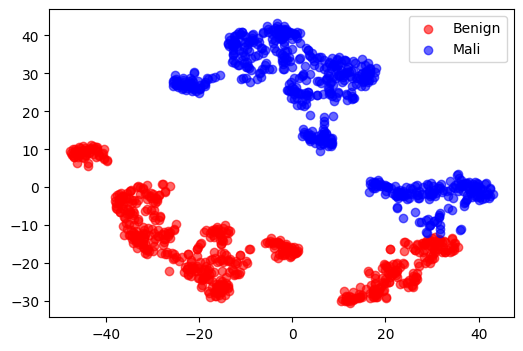

In [170]:
plot_tsne_layer_comparison(model1, model2, client_loaders[6], device)